# Quick Backbone Comparison (Local)

Fast test on a small subset (~5K train, 1K val) to compare all 4 backbones before full Colab training.

**3 epochs, ~10-15 min totali su M4.**

In [1]:
import sys, json, time, random, copy
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import (
    resnet50, ResNet50_Weights,
    resnet101, ResNet101_Weights,
    efficientnet_b3, EfficientNet_B3_Weights,
    convnext_small, ConvNeXt_Small_Weights,
)
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm.notebook import tqdm

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
IMG_SIZE = 128
BATCH_SIZE = 64
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Quick test config
TRAIN_SIZE = 5000
VAL_SIZE = 1000
NUM_EPOCHS = 3

print(f"Device: {DEVICE}")
print(f"Quick test: {TRAIN_SIZE} train / {VAL_SIZE} val / {NUM_EPOCHS} epochs")

Device: mps
Quick test: 5000 train / 1000 val / 3 epochs


## 1. Load & Sample Data

In [2]:
# Parse PKLot
print("Parsing PKLot...")
with open(DATA_DIR / "PKLot" / "samples.json") as f:
    pklot_raw = json.load(f)

all_records = []
for sample in tqdm(pklot_raw["samples"], desc="Extracting patches"):
    img_path = DATA_DIR / "PKLot" / sample["filepath"]
    for space in sample["parking_spaces"]["polylines"]:
        points = space["points"]
        if not points or not points[0]:
            continue
        coords = points[0]
        xs = [p[0] for p in coords]
        ys = [p[1] for p in coords]
        bbox = [min(xs), min(ys), max(xs), max(ys)]
        label = 1 if space["occupancy_status"] == "occupied" else 0
        all_records.append((str(img_path), bbox, label))

print(f"Total: {len(all_records)} patches")

# Stratified subsample for quick test
rng = random.Random(SEED)
occupied = [r for r in all_records if r[2] == 1]
empty = [r for r in all_records if r[2] == 0]
rng.shuffle(occupied)
rng.shuffle(empty)

# Balanced subset
half_train = TRAIN_SIZE // 2
half_val = VAL_SIZE // 2
train_records = occupied[:half_train] + empty[:half_train]
val_records = occupied[half_train:half_train+half_val] + empty[half_train:half_train+half_val]
rng.shuffle(train_records)
rng.shuffle(val_records)

print(f"Subset: train={len(train_records)}, val={len(val_records)} (balanced 50/50)")

Parsing PKLot...


Extracting patches:   0%|          | 0/12416 [00:00<?, ?it/s]

Total: 711856 patches
Subset: train=5000, val=1000 (balanced 50/50)


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class PKLotPatchDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform
        self._img_cache_path = None
        self._img_cache = None

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        img_path, bbox, label = self.records[idx]
        if self._img_cache_path != img_path:
            self._img_cache = Image.open(img_path).convert("RGB")
            self._img_cache_path = img_path
        img = self._img_cache
        w, h = img.size
        crop = img.crop((int(bbox[0]*w), int(bbox[1]*h), int(bbox[2]*w), int(bbox[3]*h)))
        if self.transform:
            crop = self.transform(crop)
        return crop, label


train_ds = PKLotPatchDataset(train_records, transform=train_transform)
val_ds = PKLotPatchDataset(val_records, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
print(f"Batch: {images.shape}, labels: {labels[:10]}")

Batch: torch.Size([64, 3, 128, 128]), labels: tensor([0, 1, 1, 0, 0, 0, 1, 0, 0, 1])


## 2. Models & Training

In [4]:
def build_resnet50():
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(2048, 2)
    for name, param in model.named_parameters():
        if not any(name.startswith(l) for l in ["layer2", "layer3", "layer4", "fc"]):
            param.requires_grad_(False)
    return model

def build_resnet101():
    model = resnet101(weights=ResNet101_Weights.DEFAULT)
    model.fc = nn.Linear(2048, 2)
    for name, param in model.named_parameters():
        if not any(name.startswith(l) for l in ["layer2", "layer3", "layer4", "fc"]):
            param.requires_grad_(False)
    return model

def build_efficientnet_b3():
    model = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 2)
    for i, block in enumerate(model.features):
        if i < 5:
            for param in block.parameters():
                param.requires_grad_(False)
    return model

def build_convnext_small():
    model = convnext_small(weights=ConvNeXt_Small_Weights.DEFAULT)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 2)
    for i, stage in enumerate(model.features):
        if i < 4:
            for param in stage.parameters():
                param.requires_grad_(False)
    return model

MODELS = {
    "ResNet50": build_resnet50,
    "ResNet101": build_resnet101,
    "EfficientNet-B3": build_efficientnet_b3,
    "ConvNeXt-Small": build_convnext_small,
}

for name, builder in MODELS.items():
    m = builder()
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:20s}: {total/1e6:.1f}M total, {trainable/1e6:.1f}M trainable")

ResNet50            : 23.5M total, 23.3M trainable
ResNet101           : 42.5M total, 42.3M trainable
EfficientNet-B3     : 10.7M total, 9.9M trainable
ConvNeXt-Small      : 49.5M total, 48.2M trainable


In [5]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="  train", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.3f}")
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []
    pbar = tqdm(loader, desc="  val  ", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    total = len(all_labels)
    preds, labels = np.array(all_preds), np.array(all_labels)
    return running_loss / total, accuracy_score(labels, preds), preds, labels


print("Training functions ready.")

Training functions ready.


In [6]:
results = {}
trained_models = {}

for model_name, builder_fn in MODELS.items():
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")

    model = builder_fn().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4, weight_decay=1e-4,
    )

    best_val_loss = float("inf")
    best_state = None
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    epoch_pbar = tqdm(range(NUM_EPOCHS), desc=model_name)
    for epoch in epoch_pbar:
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        epoch_pbar.set_postfix(
            tr_acc=f"{train_acc:.3f}", val_acc=f"{val_acc:.3f}",
            val_loss=f"{val_loss:.4f}", time=f"{elapsed:.0f}s"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    if best_state:
        model.load_state_dict(best_state)

    trained_models[model_name] = model
    results[model_name] = history

print(f"\nDone! All 4 models trained on {TRAIN_SIZE} samples x {NUM_EPOCHS} epochs.")


ResNet50


ResNet50:   0%|          | 0/3 [00:00<?, ?it/s]

  train:   0%|          | 0/79 [00:00<?, ?it/s]

  val  :   0%|          | 0/16 [00:00<?, ?it/s]

  train:   0%|          | 0/79 [00:00<?, ?it/s]

...

  train:   0%|          | 0/79 [00:00<?, ?it/s]

  val  :   0%|          | 0/16 [00:00<?, ?it/s]

  train:   0%|          | 0/79 [00:00<?, ?it/s]

  val  :   0%|          | 0/16 [00:00<?, ?it/s]


Done! All 4 models trained on 5000 samples x 3 epochs.


## 3. Results

In [7]:
criterion = nn.CrossEntropyLoss()

print(f"{'Model':20s} {'Val Acc':>8s} {'Val F1':>8s} {'Prec':>8s} {'Recall':>8s}")
print("-" * 54)

summary = {}
for name, model in trained_models.items():
    _, acc, preds, labels = evaluate(model, val_loader, criterion)
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    summary[name] = {"acc": acc, "f1": f1, "prec": prec, "rec": rec, "preds": preds, "labels": labels}
    print(f"{name:20s} {acc:8.4f} {f1:8.4f} {prec:8.4f} {rec:8.4f}")

best = max(summary, key=lambda k: summary[k]["f1"])
print(f"\nBest: {best} (F1={summary[best]['f1']:.4f})")

Model                 Val Acc   Val F1     Prec   Recall
------------------------------------------------------


  val  :   0%|          | 0/16 [00:00<?, ?it/s]

ResNet50               0.9840   0.9843   0.9690   1.0000


  val  :   0%|          | 0/16 [00:00<?, ?it/s]

ResNet101              0.9810   0.9813   0.9652   0.9980


  val  :   0%|          | 0/16 [00:00<?, ?it/s]

EfficientNet-B3        0.9830   0.9833   0.9671   1.0000


  val  :   0%|          | 0/16 [00:00<?, ?it/s]

ConvNeXt-Small         0.9840   0.9842   0.9745   0.9940

Best: ResNet50 (F1=0.9843)


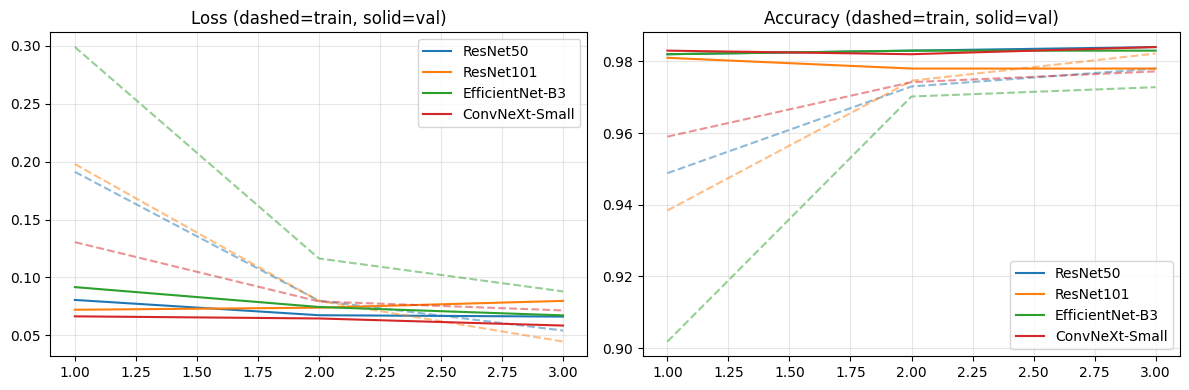

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, (name, hist) in enumerate(results.items()):
    epochs = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(epochs, hist["train_loss"], "--", color=colors[i], alpha=0.5)
    axes[0].plot(epochs, hist["val_loss"], "-", color=colors[i], label=name)
    axes[1].plot(epochs, hist["train_acc"], "--", color=colors[i], alpha=0.5)
    axes[1].plot(epochs, hist["val_acc"], "-", color=colors[i], label=name)

axes[0].set_title("Loss (dashed=train, solid=val)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Accuracy (dashed=train, solid=val)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
print(f"Inference speed (batch=20, simulating 20 bays):\n")
print(f"{'Model':20s} {'MPS (ms)':>10s} {'CPU (ms)':>10s}")
print("-" * 42)

@torch.no_grad()
def bench(model, device, n=30):
    model = model.to(device).eval()
    x = torch.randn(20, 3, IMG_SIZE, IMG_SIZE, device=device)
    for _ in range(5):  # warmup
        model(x)
    times = []
    for _ in range(n):
        t0 = time.time()
        model(x)
        if device.type == "mps":
            torch.mps.synchronize()
        times.append((time.time() - t0) * 1000)
    return np.median(times)

for name, model in trained_models.items():
    mps_ms = bench(model, DEVICE)
    cpu_ms = bench(model, torch.device("cpu"), n=10)
    print(f"{name:20s} {mps_ms:8.1f}ms {cpu_ms:8.1f}ms")

Inference speed (batch=20, simulating 20 bays):

Model                  MPS (ms)   CPU (ms)
------------------------------------------
ResNet50                 38.1ms    766.7ms
ResNet101                59.4ms   1240.3ms
EfficientNet-B3          34.6ms    818.8ms
ConvNeXt-Small           75.2ms    514.3ms


In [ ]:
# Save trained weights for use in visual test notebook
export_dir = PROJECT_ROOT / "backend" / "model"
export_dir.mkdir(parents=True, exist_ok=True)

for name, model in trained_models.items():
    filename = f"occupancy_{name.lower().replace('-', '_')}_pklot.pt"
    path = export_dir / filename
    torch.save({
        "model_name": name,
        "state_dict": model.state_dict(),
        "img_size": IMG_SIZE,
        "num_classes": 2,
    }, path)
    print(f"Saved {name} → {path.name} ({path.stat().st_size / 1024 / 1024:.1f} MB)")

print("\nWeights saved. You can now run occupancy_visual_test.ipynb.")